In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

## Dataset read-in and details

In [2]:
df = pd.read_csv('./data/telco_customer_churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Feature Relationships

### What percentage of customers churned?

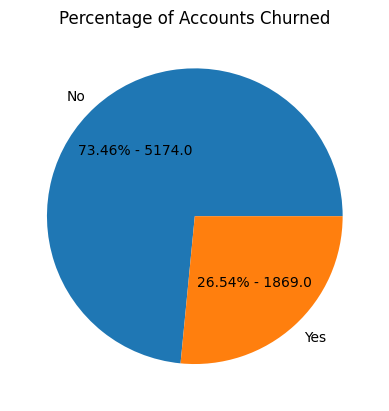

In [8]:
churned_values = df["Churn"].value_counts()
labels = df["Churn"].unique()
total = len(df["Churn"])

def get_autopct(values):
    def make_autopct(val):
        a =  np.round(val*total/100, 0)
        return "{:.2f}% - {}".format(val, a)
    return make_autopct
        

plt.pie(data=df, x=churned_values, labels=labels, autopct=get_autopct(churned_values))
plt.title("Percentage of Accounts Churned")
plt.show()

### Which features are most predictive of whether a customer churns?

In [9]:
# Need binary churned values
df_copy = df.copy()
binary_mappings = {
    "gender":{"Male":0, "Female":1},
    "Partner":{"No":0, "Yes":1},
    "Dependents":{"No":0, "Yes":1},
    "PhoneService":{"No":0, "Yes":1},
    "PaperlessBilling":{"No":0, "Yes":1},
    "Churn":{"No":0, "Yes":1},
}
for feature, val in binary_mappings.items():
    df_copy[feature] = df_copy[feature].map(val)

df_copy.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,0,1,0,1,0,No phone service,DSL,No,...,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,0,0,0,0,34,1,No,DSL,Yes,...,Yes,No,No,No,One year,0,Mailed check,56.95,1889.5,0
2,3668-QPYBK,0,0,0,0,2,1,No,DSL,Yes,...,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,0,0,0,0,45,0,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,1,0,0,0,2,1,No,Fiber optic,No,...,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [10]:
df_copy[['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']].corr()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,PaperlessBilling,Churn
gender,1.000000,0.001874,0.001808,-0.010517,0.006488,0.011754,0.008612
SeniorCitizen,0.001874,1.000000,0.016479,-0.211185,0.008576,0.156530,0.150889
Partner,0.001808,0.016479,1.000000,0.452676,0.017706,-0.014877,-0.150448
Dependents,-0.010517,-0.211185,0.452676,1.000000,-0.001762,-0.111377,-0.164221
PhoneService,0.006488,0.008576,0.017706,-0.001762,1.000000,0.016505,0.011942
PaperlessBilling,0.011754,0.156530,-0.014877,-0.111377,0.016505,1.000000,0.191825
Churn,0.008612,0.150889,-0.150448,-0.164221,0.011942,0.191825,1.000000


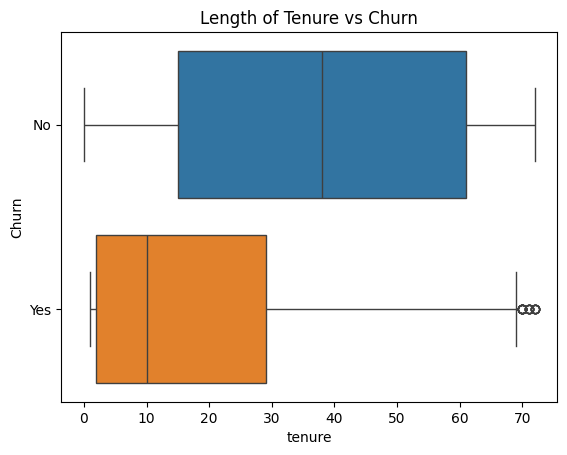

In [11]:
sns.boxplot(data=df, x='tenure', y = 'Churn', hue='Churn')
plt.title("Length of Tenure vs Churn")
plt.show()

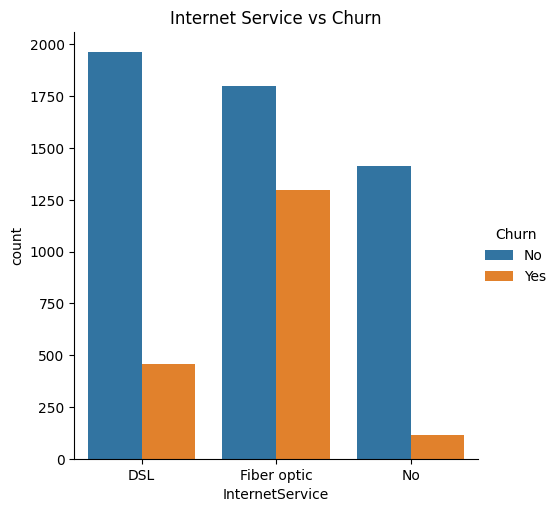

In [12]:
sns.catplot(kind='count', data=df,  x='InternetService', hue='Churn')
plt.title("Internet Service vs Churn")
plt.show()

Text(0.5, 1.0, 'Gender vs Churn')

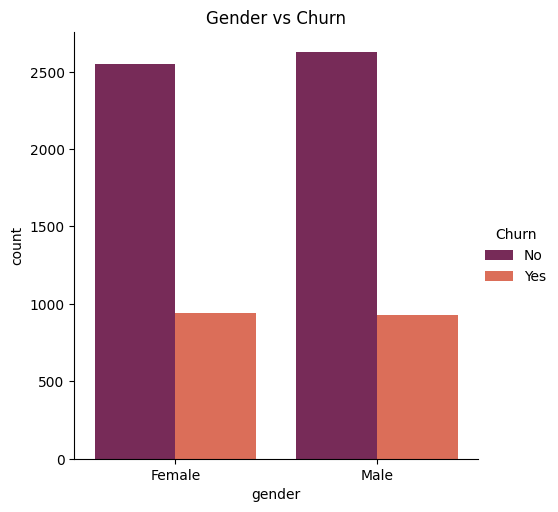

In [13]:
sns.catplot(kind='count', data=df, x='gender', hue='Churn', palette='rocket')
plt.title('Gender vs Churn')

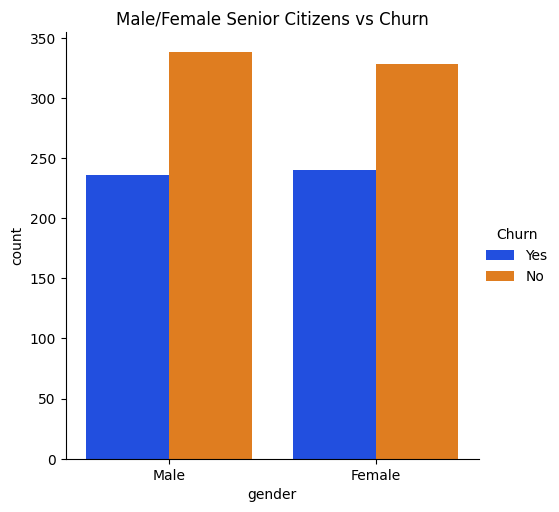

In [14]:
is_senior = df[df['SeniorCitizen'] == 1]
sns.catplot(kind='count', data=is_senior, x='gender', hue='Churn', palette='bright')
plt.title('Male/Female Senior Citizens vs Churn')
plt.show()

## Monthly and Total Charges Affect Churn?

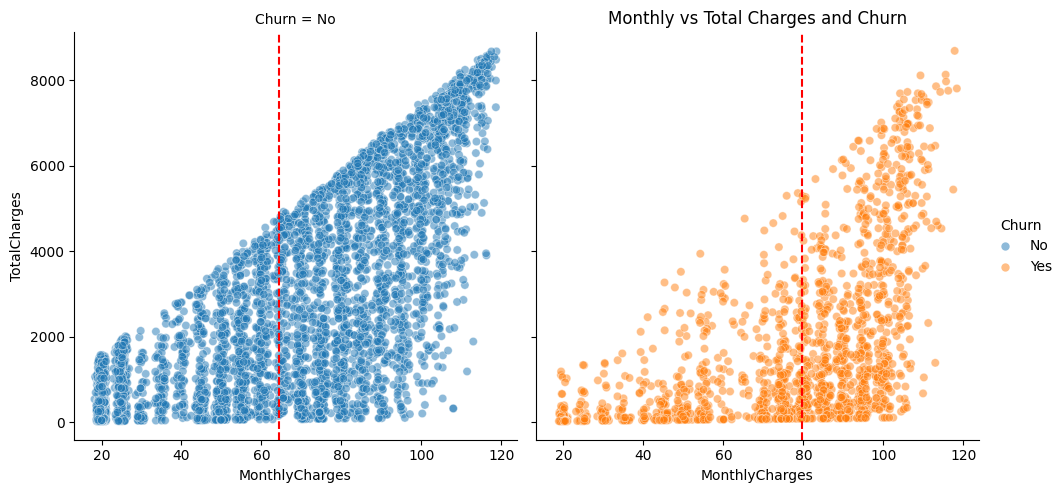

In [15]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
g = sns.relplot(kind='scatter', data=df, x='MonthlyCharges', y='TotalCharges', col='Churn', hue='Churn', alpha=0.5)
medians = df.groupby('Churn')['MonthlyCharges'].median()
for ax, churn_value in zip(g.axes.flatten(), medians.index):
    ax.axvline(x=medians[churn_value], color='red', linestyle='--')
plt.title('Monthly vs Total Charges and Churn')
plt.show()

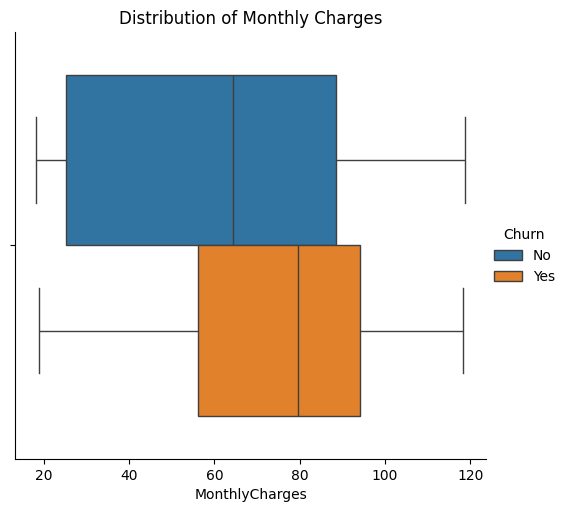

In [16]:
sns.catplot(kind='box', data=df, x='MonthlyCharges', hue='Churn')
plt.title('Distribution of Monthly Charges')
plt.show()

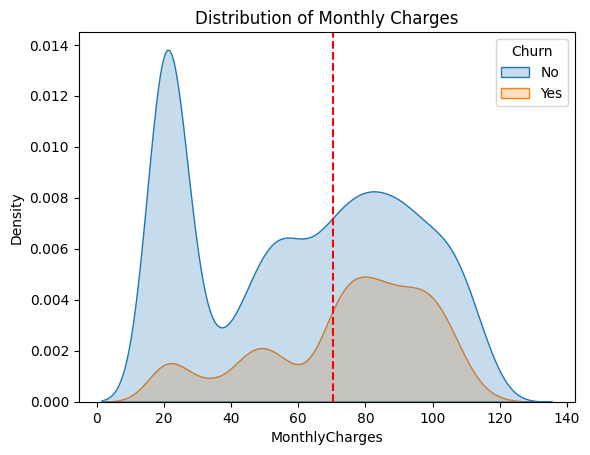

In [17]:
ax = sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True)
ax.axvline(x=df['MonthlyCharges'].median(), color='red', linestyle='--')
plt.title("Distribution of Monthly Charges")
plt.show()

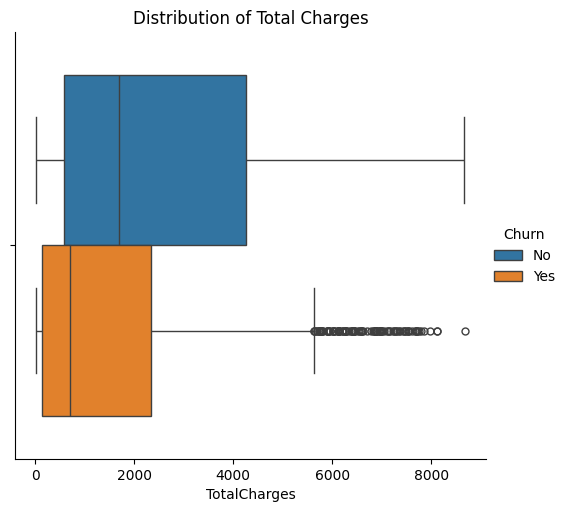

In [18]:
sns.catplot(kind='box', data=df, x='TotalCharges', hue='Churn')
plt.title('Distribution of Total Charges')
plt.show()

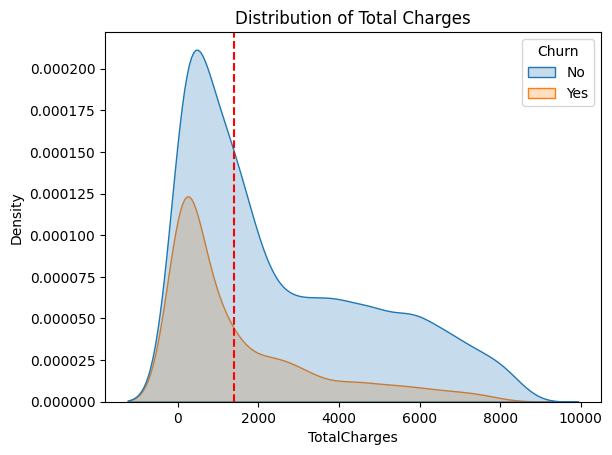

In [19]:
ax = sns.kdeplot(data=df, x='TotalCharges', hue='Churn', fill=True)
ax.axvline(x=df['TotalCharges'].median(), color='red', linestyle='--')
plt.title("Distribution of Total Charges")
plt.show()

In [20]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [21]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

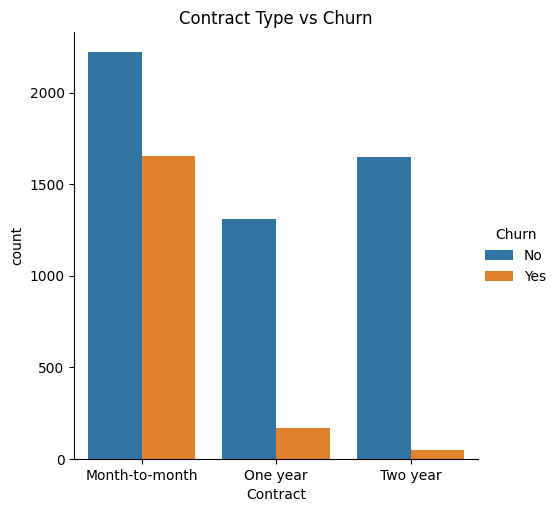

In [22]:
sns.catplot(kind='count', data=df, x='Contract', hue='Churn')
plt.title('Contract Type vs Churn')
plt.show()

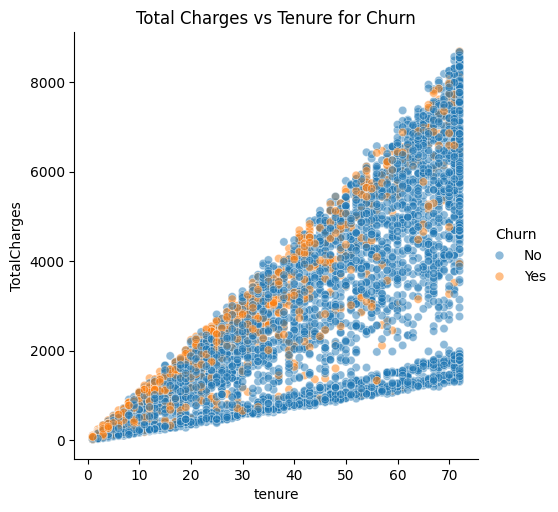

In [23]:
sns.relplot(kind='scatter', data=df, x='tenure', y='TotalCharges', hue='Churn', alpha=0.5)
plt.title('Total Charges vs Tenure for Churn')
plt.show()

In [24]:
df_copy['tenure_bin'] = pd.cut(df_copy['tenure'], bins=10)
df_copy.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_bin
0,7590-VHVEG,1,0,1,0,1,0,No phone service,DSL,No,...,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0,"(-0.072, 7.2]"
1,5575-GNVDE,0,0,0,0,34,1,No,DSL,Yes,...,No,No,No,One year,0,Mailed check,56.95,1889.5,0,"(28.8, 36.0]"
2,3668-QPYBK,0,0,0,0,2,1,No,DSL,Yes,...,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1,"(-0.072, 7.2]"
3,7795-CFOCW,0,0,0,0,45,0,No phone service,DSL,Yes,...,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0,"(43.2, 50.4]"
4,9237-HQITU,1,0,0,0,2,1,No,Fiber optic,No,...,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1,"(-0.072, 7.2]"


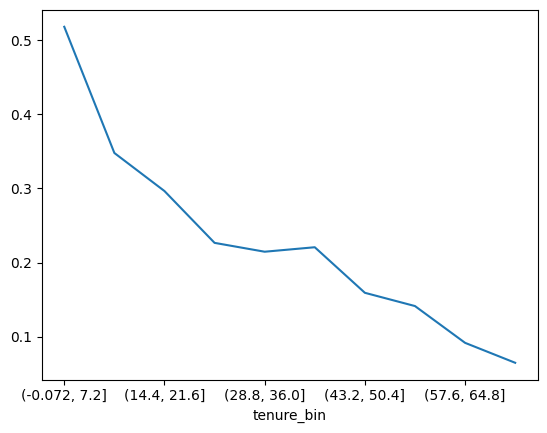

In [25]:
df_copy.groupby('tenure_bin', observed=True)['Churn'].mean().plot()
plt.show()

### Train/Test

#### Need one-hot encoding for categorical values: Contract and Internet Service

In [26]:
df_copy = pd.get_dummies(
    df_copy,
    prefix=['contract', 'internet_service'],
    columns=['Contract', 'InternetService'],
    dtype=int
)

In [57]:
df_copy['TotalCharges'] = pd.to_numeric(df_copy['TotalCharges'], errors='coerce')

In [60]:
df_copy['TotalCharges'] = df_copy['TotalCharges'].fillna(df_copy['TotalCharges'].mean())
df_copy.isnull().sum()

customerID                      0
gender                          0
SeniorCitizen                   0
Partner                         0
Dependents                      0
tenure                          0
PhoneService                    0
MultipleLines                   0
OnlineSecurity                  0
OnlineBackup                    0
DeviceProtection                0
TechSupport                     0
StreamingTV                     0
StreamingMovies                 0
PaperlessBilling                0
PaymentMethod                   0
MonthlyCharges                  0
TotalCharges                    0
Churn                           0
tenure_bin                      0
contract_Month-to-month         0
contract_One year               0
contract_Two year               0
internet_service_DSL            0
internet_service_Fiber optic    0
internet_service_No             0
dtype: int64

In [61]:
features = df_copy[['contract_Month-to-month','contract_One year', 'contract_Two year', 'tenure', 'internet_service_DSL', 'internet_service_Fiber optic', 'internet_service_No', 'MonthlyCharges', 'TotalCharges']].values
target = df_copy['Churn'].values

X_train, X_test, Y_train, Y_test = train_test_split(features, target, test_size=0.4, random_state=42)

### Scaling

In [68]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

### Model Fit

In [69]:
X_train

array([[ 0.91922694, -0.52393683, -0.56596157, ..., -0.53090187,
         0.183178  , -0.95448868],
       [ 0.91922694, -0.52393683, -0.56596157, ..., -0.53090187,
        -0.6877853 , -0.99345798],
       [ 0.91922694, -0.52393683, -0.56596157, ..., -0.53090187,
        -0.0122092 , -0.21841422],
       ...,
       [ 0.91922694, -0.52393683, -0.56596157, ...,  1.88358726,
        -1.44449676, -0.8779387 ],
       [ 0.91922694, -0.52393683, -0.56596157, ..., -0.53090187,
         1.14852326, -0.48379337],
       [-1.08787064,  1.90862703, -0.56596157, ...,  1.88358726,
        -1.489204  , -0.81126329]], shape=(4225, 9))

In [63]:
Y_train

array([0, 0, 0, ..., 0, 1, 0], shape=(4225,))

## Logistic regression

In [70]:
lm_model = LogisticRegression(random_state=42, max_iter = 1000, verbose=True)
lm_model.fit(X_train, Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

#### Evaluation

In [73]:
y_pred = lm_model.predict(X_test)
print(confusion_matrix(Y_test, y_pred))

[[1878  191]
 [ 367  382]]


In [75]:
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      2069
           1       0.67      0.51      0.58       749

    accuracy                           0.80      2818
   macro avg       0.75      0.71      0.72      2818
weighted avg       0.79      0.80      0.79      2818



In [81]:
y_score = lm_model.predict_proba(X_test)[:,1]
print(roc_auc_score(Y_test, y_score))

0.8504192153094734


### Random Forest Classifier

In [82]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [84]:
y_pred = rf_model.predict(X_test)
y_score = rf_model.predict_proba(X_test)[:,1]
print(confusion_matrix(Y_test, y_pred))
print(classification_report(Y_test, y_pred))
print(roc_auc_score(Y_test, y_pred))

[[1826  243]
 [ 374  375]]
              precision    recall  f1-score   support

           0       0.83      0.88      0.86      2069
           1       0.61      0.50      0.55       749

    accuracy                           0.78      2818
   macro avg       0.72      0.69      0.70      2818
weighted avg       0.77      0.78      0.77      2818

0.6916097571048494


### XGBoost